In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc
import tensorflow as tf
import gc
import optuna
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1779521380.762380     518 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779521381.185034     518 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779521382.758568     518 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Загрузка и предобработка

In [2]:
from datasets import load_dataset

ds = load_dataset("Ewakaa/pneumonia_classification_chest_xray")

In [3]:
# ================================================================
# Структура
# ================================================================

ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4077
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1165
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 582
    })
})

In [4]:
# ================================================================
# Баланс классов
# ================================================================

from collections import Counter

print("Тренировочных данные...")
counts = Counter(ds['train']['label'])
print(counts)
print()

print("Валидационные данные...")
counts = Counter(ds['validation']['label'])
print(counts)
print()

print("Тестовые данные...")
counts = Counter(ds['test']['label'])
print(counts)

Тренировочных данные...
Counter({1: 2973, 0: 1104})

Валидационные данные...
Counter({1: 861, 0: 304})

Тестовые данные...
Counter({1: 411, 0: 171})


В обучающей выборке класс 1 (Пневмония) встречается почти в 2.7 раза чаще, чем класс 0 (Норма).

Пневмония: ~73% данных.

Норма: ~27% данных.

Если тренировать модель «как есть», возникнут две проблемы:

1. Ловушка Accuracy: модель может просто научиться всегда отвечать «Пневмония». Даже если она не посмотрит на картинку, её точность будет ~73%, что выглядит неплохо на бумаге, но абсолютно бесполезно на практике.

2. Проблема «пропуска цели»: в медицине ошибка, когда мы не заметили болезнь (False Negative), гораздо опаснее, чем ложная тревога. Из-за малого количества примеров «Нормы», модель может хуже выучить признаки здоровых легких.

Хорошая новость в том, что пропорция сохраняется во всех частях (Train/Val/Test). Это значит, что валидация будет адекватно отражать то, как модель поведет себя на тесте.

In [5]:
# ================================================================
# Глобальные константы
# ================================================================

IMG_SIZE = (96, 96) # Стандартный размер для большинства моделей
BATCH_SIZE = 32
EPOCHS = 20

In [6]:
# ================================================================
# Функция предобработки
# ================================================================

def preprocess_data(dataset_split):
    images = []
    labels = []
    
    for item in dataset_split:
        # Извлекаем изображение и метку
        img = item['image']
        label = item['label']
        
        # Конвертируем в RGB (если вдруг есть ч/б) и меняем размер
        img = img.convert("RGB").resize(IMG_SIZE)
        
        # Превращаем в массив и нормализуем (0-1)
        img_array = np.array(img) / 255.0
        
        images.append(img_array)
        labels.append(label)
    
    return np.array(images), np.array(labels)

In [7]:
%%time
# ================================================================
# Предобработка
# ================================================================

print("Тренировочных данные...")
x_train, y_train = preprocess_data(ds['train'])
print()

print("Валидационные данные...")
x_val, y_val = preprocess_data(ds['validation'])
print()

print("Тестовые данные...")
x_test, y_test = preprocess_data(ds['test'])
print()

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_val shape:   {x_val.shape}, y_val shape:   {y_val.shape}")
print(f"x_test shape:  {x_test.shape}, y_test shape:  {y_test.shape}")

Тренировочных данные...

Валидационные данные...

Тестовые данные...

x_train shape: (4077, 96, 96, 3), y_train shape: (4077,)
x_val shape:   (1165, 96, 96, 3), y_val shape:   (1165,)
x_test shape:  (582, 96, 96, 3), y_test shape:  (582,)
CPU times: user 13.8 s, sys: 997 ms, total: 14.8 s
Wall time: 13.6 s


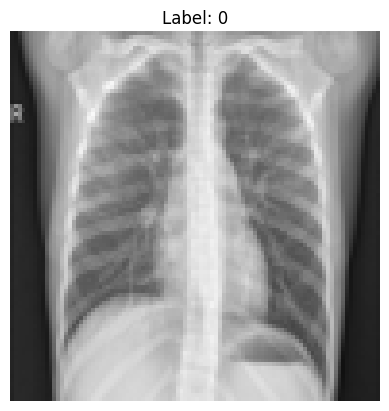

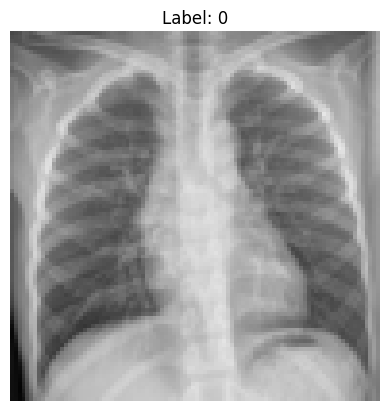

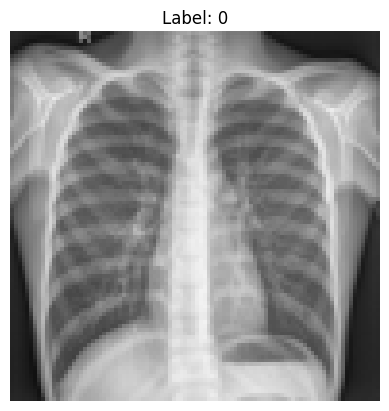

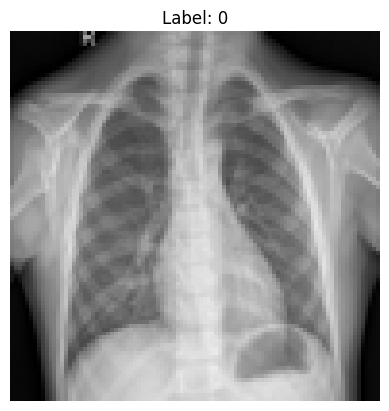

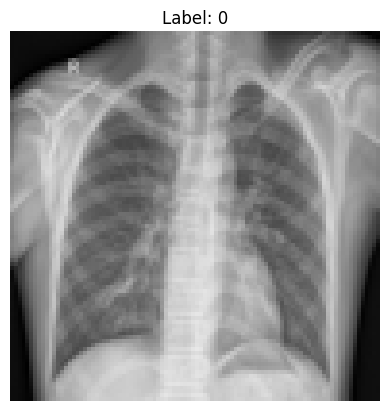

In [8]:
# ================================================================
# Изображения
# ================================================================

for i in range(5):

    plt.imshow(x_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
    plt.show()

In [9]:
print('x_train[0] — это первое изображение целиком')
print(x_train[0])

x_train[0] — это первое изображение целиком
[[[0.11764706 0.11764706 0.11764706]
  [0.10588235 0.10588235 0.10588235]
  [0.20784314 0.20784314 0.20784314]
  ...
  [0.50196078 0.50196078 0.50196078]
  [0.47843137 0.47843137 0.47843137]
  [0.40392157 0.40392157 0.40392157]]

 [[0.12156863 0.12156863 0.12156863]
  [0.10588235 0.10588235 0.10588235]
  [0.18039216 0.18039216 0.18039216]
  ...
  [0.50588235 0.50588235 0.50588235]
  [0.47058824 0.47058824 0.47058824]
  [0.39607843 0.39607843 0.39607843]]

 [[0.11764706 0.11764706 0.11764706]
  [0.10980392 0.10980392 0.10980392]
  [0.15686275 0.15686275 0.15686275]
  ...
  [0.50196078 0.50196078 0.50196078]
  [0.4627451  0.4627451  0.4627451 ]
  [0.38431373 0.38431373 0.38431373]]

 ...

 [[0.1372549  0.1372549  0.1372549 ]
  [0.16078431 0.16078431 0.16078431]
  [0.15686275 0.15686275 0.15686275]
  ...
  [0.12941176 0.12941176 0.12941176]
  [0.12941176 0.12941176 0.12941176]
  [0.11764706 0.11764706 0.11764706]]

 [[0.13333333 0.13333333 0.133

In [10]:
print('x_train[0, 0] — это первая строка пикселей (верхний край) первого изображения')
print(x_train[0, 0])

x_train[0, 0] — это первая строка пикселей (верхний край) первого изображения
[[0.11764706 0.11764706 0.11764706]
 [0.10588235 0.10588235 0.10588235]
 [0.20784314 0.20784314 0.20784314]
 [0.34509804 0.34509804 0.34509804]
 [0.42745098 0.42745098 0.42745098]
 [0.50980392 0.50980392 0.50980392]
 [0.54509804 0.54509804 0.54509804]
 [0.56862745 0.56862745 0.56862745]
 [0.58431373 0.58431373 0.58431373]
 [0.62352941 0.62352941 0.62352941]
 [0.70196078 0.70196078 0.70196078]
 [0.7372549  0.7372549  0.7372549 ]
 [0.72156863 0.72156863 0.72156863]
 [0.70588235 0.70588235 0.70588235]
 [0.71764706 0.71764706 0.71764706]
 [0.73333333 0.73333333 0.73333333]
 [0.69019608 0.69019608 0.69019608]
 [0.64313725 0.64313725 0.64313725]
 [0.64705882 0.64705882 0.64705882]
 [0.65882353 0.65882353 0.65882353]
 [0.6745098  0.6745098  0.6745098 ]
 [0.69019608 0.69019608 0.69019608]
 [0.70196078 0.70196078 0.70196078]
 [0.67058824 0.67058824 0.67058824]
 [0.65882353 0.65882353 0.65882353]
 [0.63137255 0.6313725

In [11]:
print('x_train[0, 0, 0] — это один конкретный пиксель (в левом верхнем углу), представленный тремя числами [R, G, B]')
print(x_train[0, 0, 0])

x_train[0, 0, 0] — это один конкретный пиксель (в левом верхнем углу), представленный тремя числами [R, G, B]
[0.11764706 0.11764706 0.11764706]


# Простейшая FCNN

In [12]:
# ================================================================
# Параметры входных данных
# ================================================================

IMG_SHAPE = (96, 96, 3)

# ================================================================
# Модель FCNN
# ================================================================

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    # 1. Слой преобразования: делает из 3D картинки 1D вектор
    tf.keras.layers.Flatten(input_shape=IMG_SHAPE),
    
    # 2. Полносвязные слои
    # Увеличим количество нейронов, так как входной вектор стал огромным
    tf.keras.layers.Dense(256, activation='relu'), 
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    
    # 3. Выходной слой для бинарной классификации
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# ================================================================
# Компиляция
# ================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy', # Кросс-энтропия для классификации
    metrics=['accuracy']
)

model.summary()

W0000 00:00:1779441699.538988   60280 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779441699.540771   60280 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779441699.741006   60280 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 27648)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,078,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,096,705 (27.07 MB)

 Trainable params: 7,096,705 (27.07 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
%%time

# ================================================================
# Обучение модели
# ================================================================

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20


I0000 00:00:1779441701.688778   60503 service.cc:153] XLA service 0x765f800328e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779441701.688799   60503 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779441701.714609   60503 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779441701.901824   60503 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779441701.923975   60503 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1750__.11


 72/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7004 - loss: 0.7165

I0000 00:00:1779441703.563565   60503 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


123/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7244 - loss: 0.6485

I0000 00:00:1779441703.946077   60502 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1750__.11
I0000 00:00:1779441704.059625   60502 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779441704.276691   60695 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1779441704.581673   60684 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779441704.599364   60502 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a go

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7263 - loss: 0.6433

I0000 00:00:1779441706.505696   60502 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779441706.803600   60943 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1779441706.851624   60948 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 272 bytes spill stores, 272 bytes spill loads



128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7736 - loss: 0.5133 - val_accuracy: 0.9159 - val_loss: 0.2813
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8590 - loss: 0.3290 - val_accuracy: 0.8712 - val_loss: 0.2837
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8950 - loss: 0.2620 - val_accuracy: 0.9150 - val_loss: 0.2038
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9043 - loss: 0.2416 - val_accuracy: 0.9365 - val_loss: 0.1761
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9129 - loss: 0.2218 - val_accuracy: 0.9416 - val_loss: 0.1702
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9009 - loss: 0.2502 - val_accuracy: 0.8944 - val_loss: 0.2325
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9061 - loss: 0.2350 - val_accuracy: 0.9365 - val_loss: 0.1769
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9102 - loss: 0.2329 - val_accuracy: 0.9433 - val

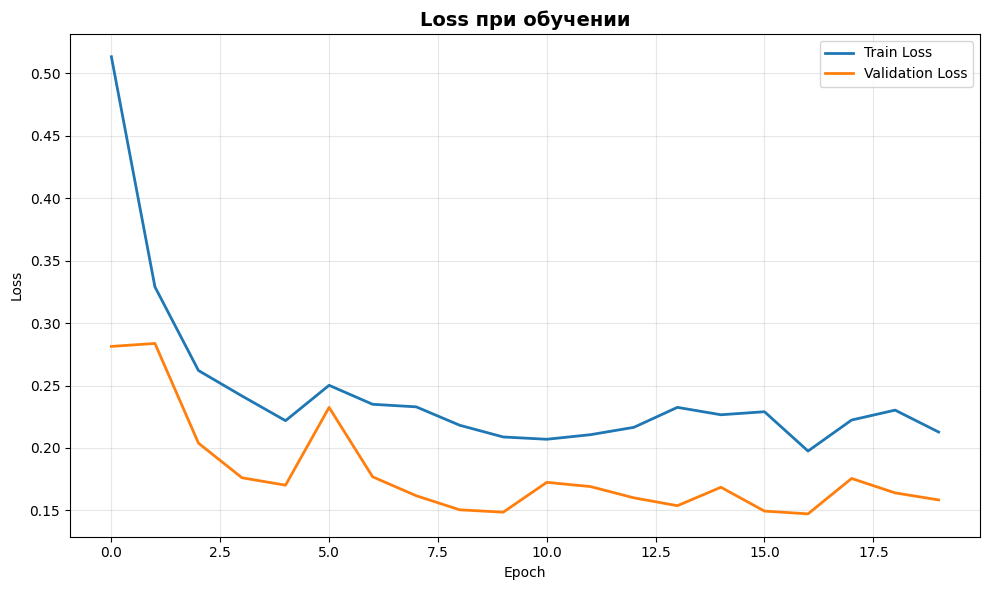

In [14]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test, verbose=1, batch_size=BATCH_SIZE)

# Если вероятность > 0.5, то это 1 (пневмония), иначе 0 (норма)
y_pred_classes = (y_pred > 0.5).astype("int32")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


In [16]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       171
           1       0.95      0.95      0.95       411

    accuracy                           0.93       582
   macro avg       0.92      0.91      0.91       582
weighted avg       0.93      0.93      0.93       582



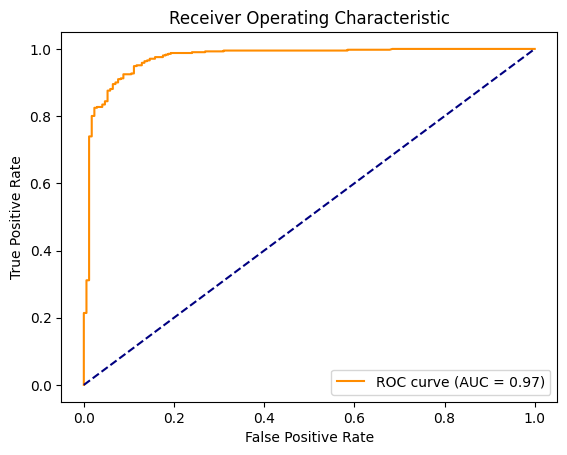

In [17]:
# ================================================================
# ROC-AUC
# ================================================================

# 1. FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Chance level
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

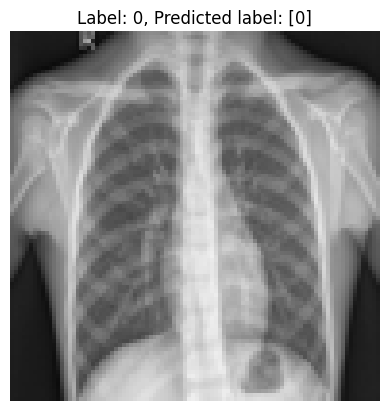

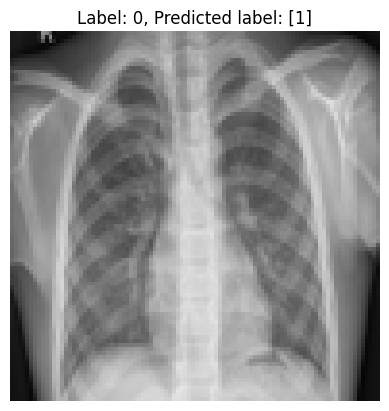

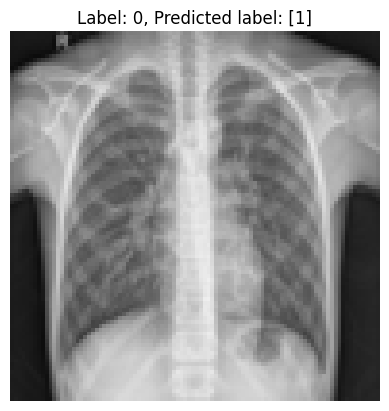

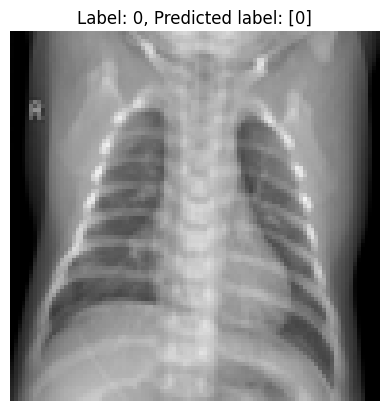

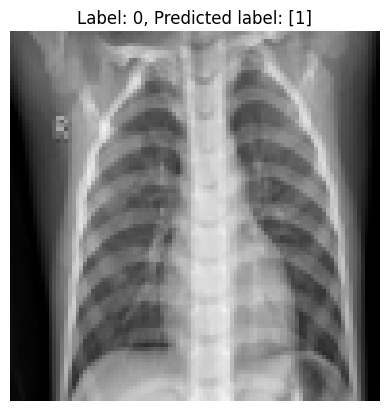

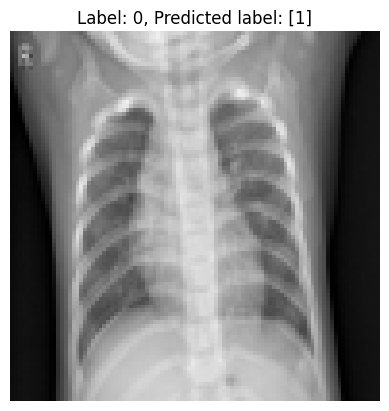

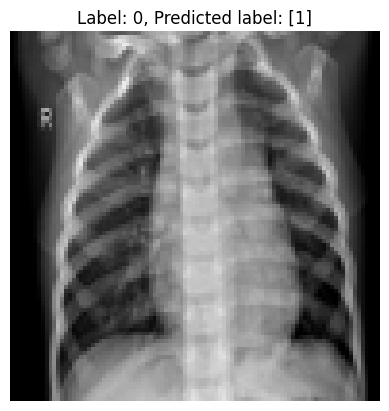

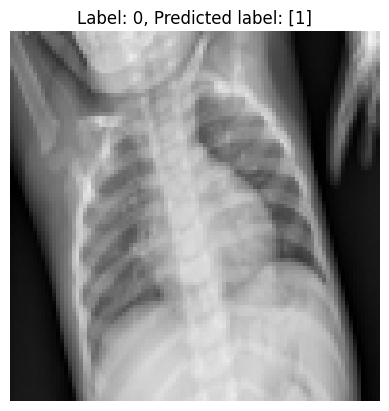

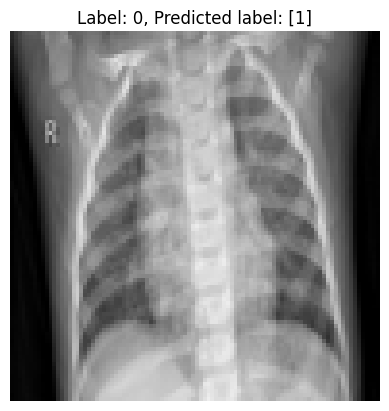

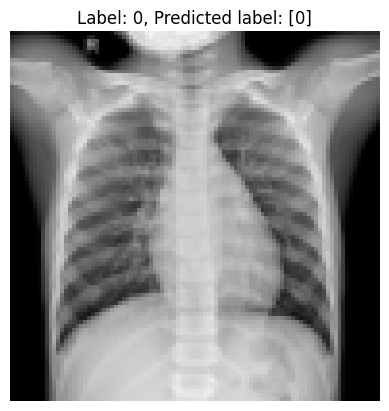

In [18]:
# ================================================================
# Изображения
# ================================================================

for i in range(10):

    plt.imshow(x_test[i])
    plt.title(f"Label: {y_test[i]}, Predicted label: {y_pred_classes[i]}")
    plt.axis('off')
    plt.show()

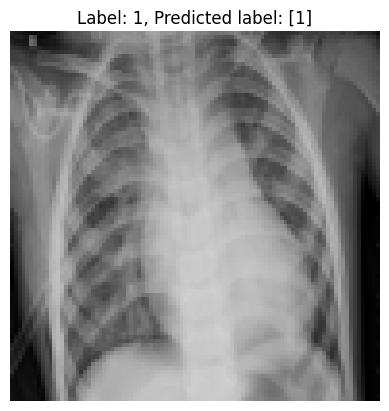

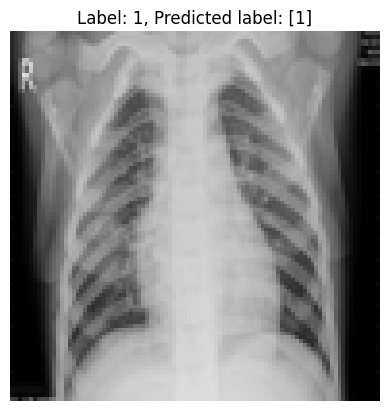

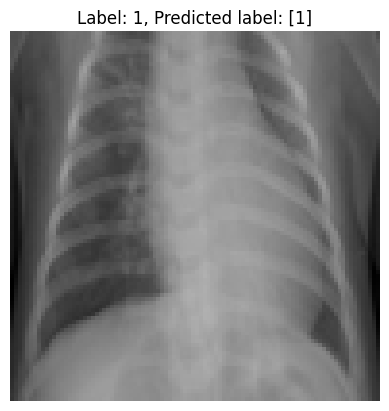

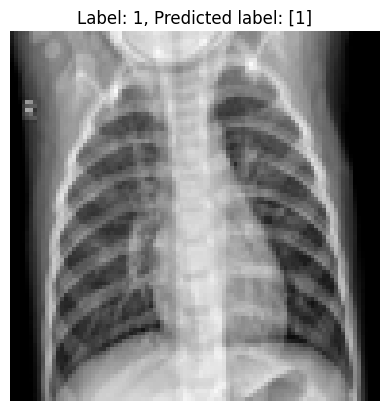

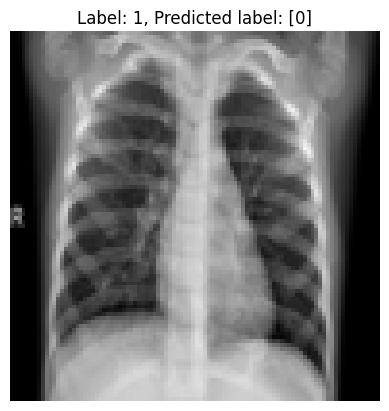

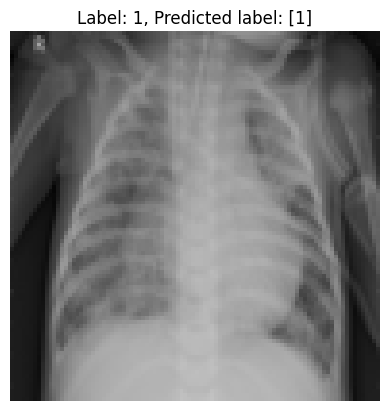

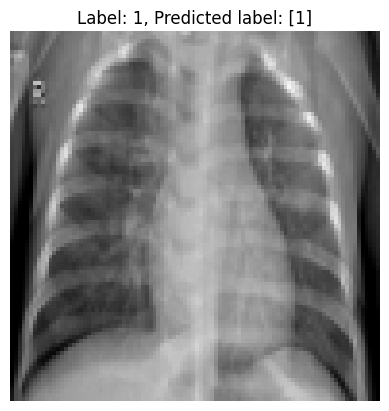

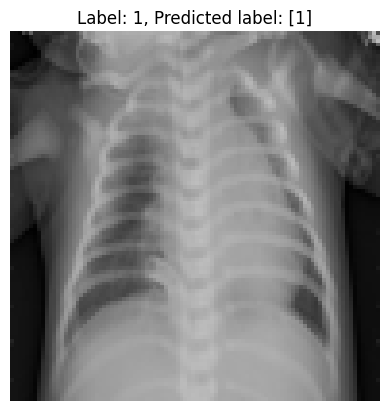

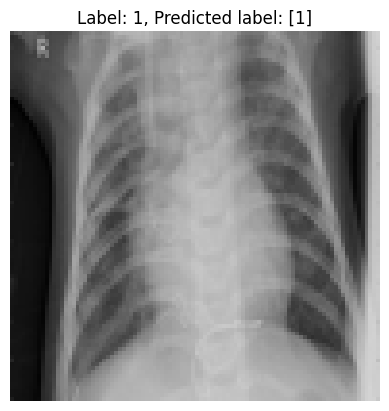

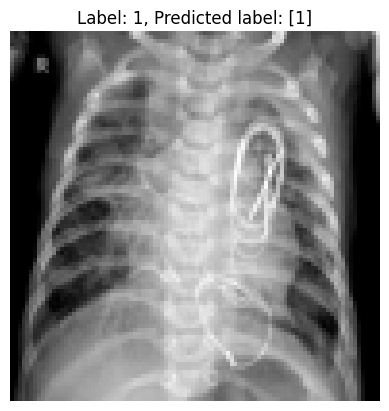

In [19]:
# ================================================================
# Изображения
# ================================================================

for i in range(10):

    plt.imshow(x_test[i+200])
    plt.title(f"Label: {y_test[i+200]}, Predicted label: {y_pred_classes[i+200]}")
    plt.axis('off')
    plt.show()

# Простейшая CNN

In [20]:
# ================================================================
# Параметры из нашей предобработки
# ================================================================

IMG_HEIGHT, IMG_WIDTH = 96, 96
CHANNELS = 3

# ================================================================
# Модель CNN
# ================================================================

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    # 1. Входной слой (ожидает картинку 96x96x3)
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
    
    # 2. Сверточный блок 1: ищем простые признаки (границы, углы)
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    # 3. Сверточный блок 2: ищем более сложные формы
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    # 4. Сверточный блок 3: глубокие признаки
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    # 5. Превращаем 2D признаки в одномерный вектор
    tf.keras.layers.Flatten(),
    
    # 6. Полносвязные слои (теперь они работают с признаками из картинок)
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Защита от переобучения
    tf.keras.layers.Dense(32, activation='relu'),
    
    # 7. Выходной слой (1 нейрон для бинарной классификации)
    # Сигмоида выдает вероятность от 0 до 1
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# ================================================================
# Компиляция
# ================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       819,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 914,625 (3.49 MB)

 Trainable params: 914,625 (3.49 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
%%time

# ================================================================
# Обучение модели
# ================================================================

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20


I0000 00:00:1779441717.276308   60501 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18424__.37
I0000 00:00:1779441718.689559   62920 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_8', 4 bytes spill stores, 4 bytes spill loads



121/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7428 - loss: 0.5728

I0000 00:00:1779441720.723683   60498 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18424__.37


128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7640 - loss: 0.5127 - val_accuracy: 0.8824 - val_loss: 0.2795
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8948 - loss: 0.2593 - val_accuracy: 0.9382 - val_loss: 0.1625
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9181 - loss: 0.2122 - val_accuracy: 0.9433 - val_loss: 0.1577
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9306 - loss: 0.1972 - val_accuracy: 0.9502 - val_loss: 0.1379
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9357 - loss: 0.1804 - val_accuracy: 0.9536 - val_loss: 0.1275
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9402 - loss: 0.1698 - val_accuracy: 0.9605 - val_loss: 0.1164
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9377 - loss: 0.1691 - val_accuracy: 0.9511 - val_loss: 0.1442
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9421 - loss: 0.1491 - val_accuracy: 0.9502 - va

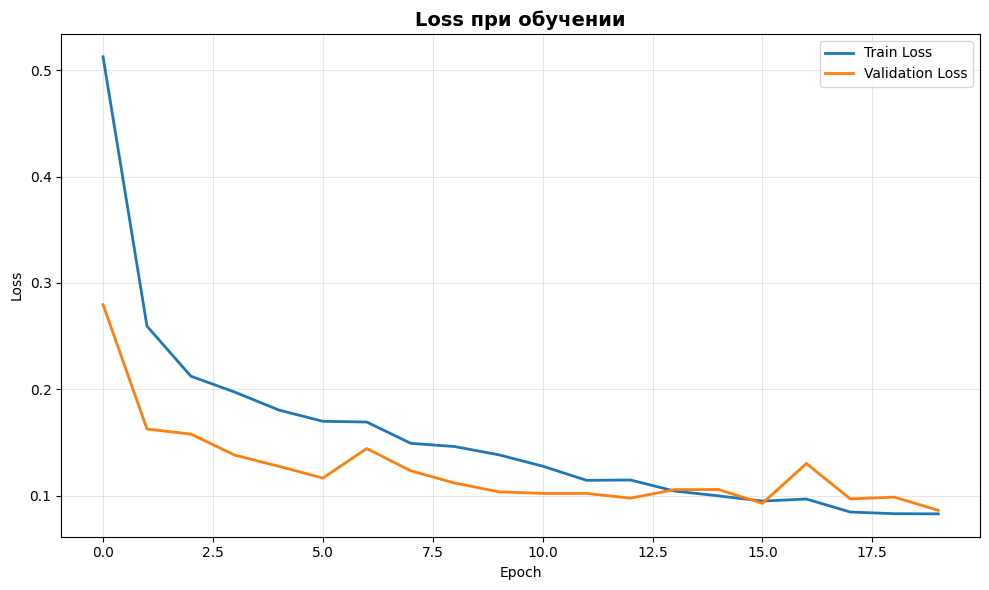

In [22]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test, verbose=1, batch_size=BATCH_SIZE)

# # Если вероятность > 0.5, то это 1 (пневмония), иначе 0 (норма)
y_pred_classes = (y_pred > 0.5).astype("int32")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


I0000 00:00:1779441738.383891   65198 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 8 bytes spill stores, 8 bytes spill loads



In [24]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       171
           1       0.97      0.96      0.96       411

    accuracy                           0.95       582
   macro avg       0.94      0.94      0.94       582
weighted avg       0.95      0.95      0.95       582



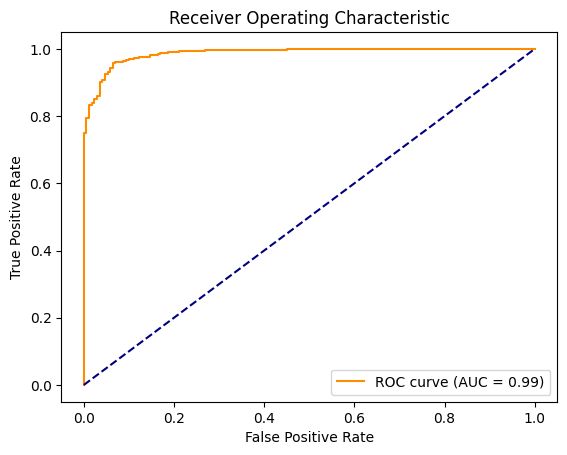

In [25]:
# ================================================================
# ROC-AUC
# ================================================================

# 1. FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Chance level
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

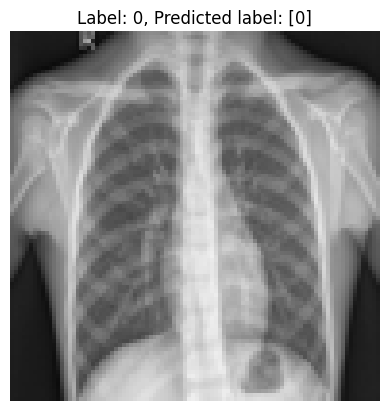

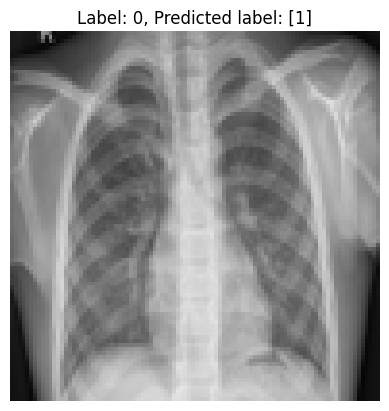

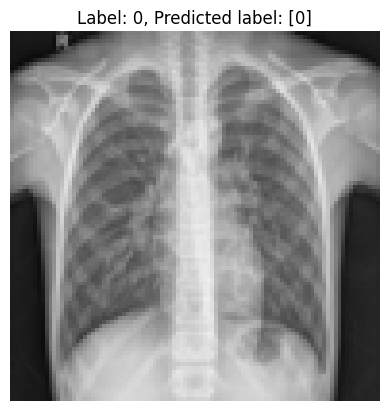

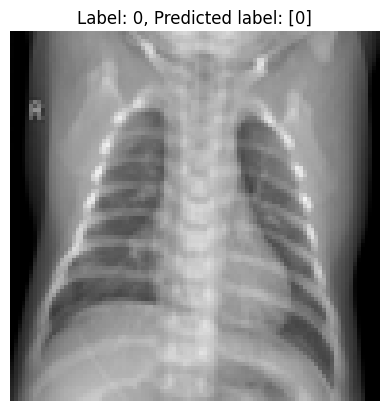

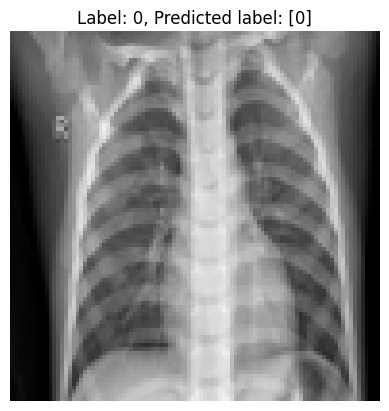

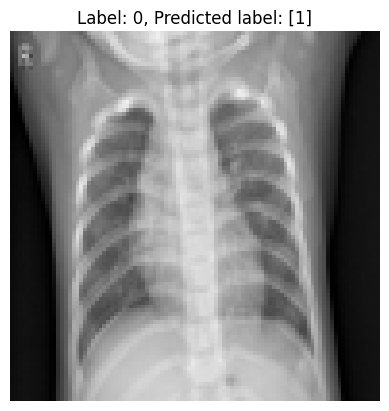

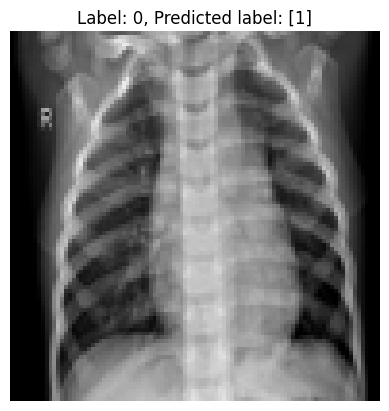

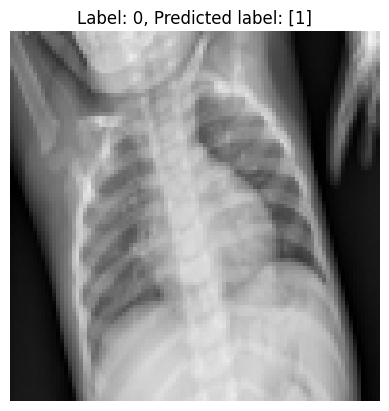

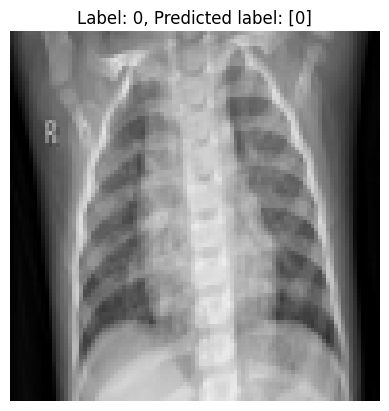

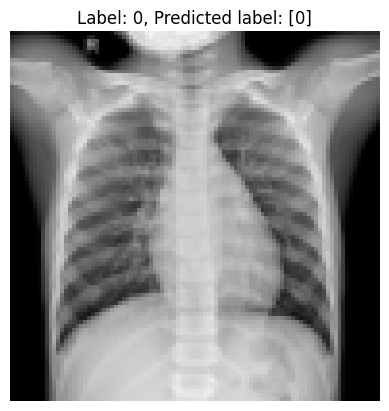

In [26]:
# ================================================================
# Изображения
# ================================================================

for i in range(10):

    plt.imshow(x_test[i])
    plt.title(f"Label: {y_test[i]}, Predicted label: {y_pred_classes[i]}")
    plt.axis('off')
    plt.show()

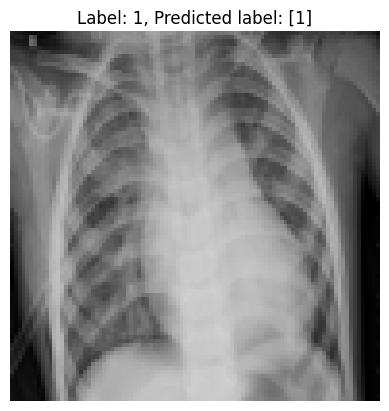

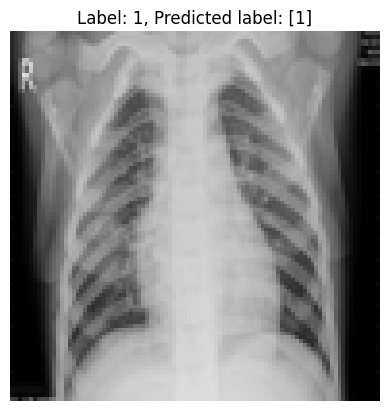

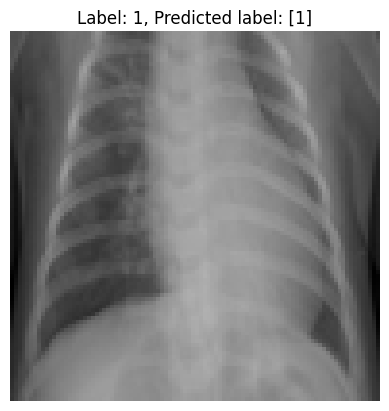

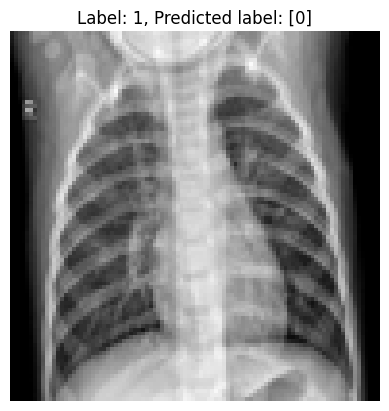

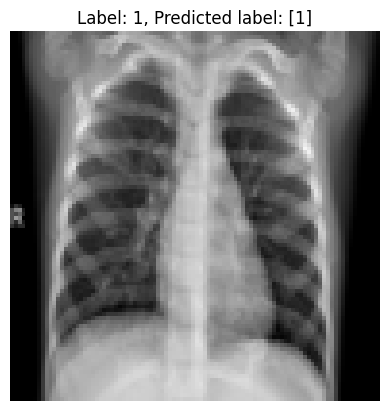

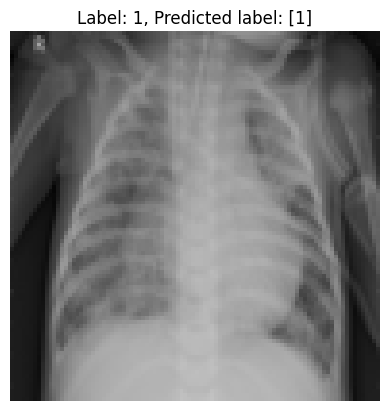

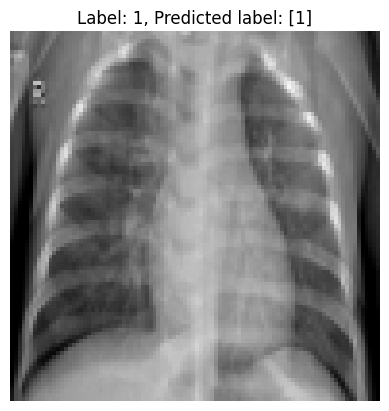

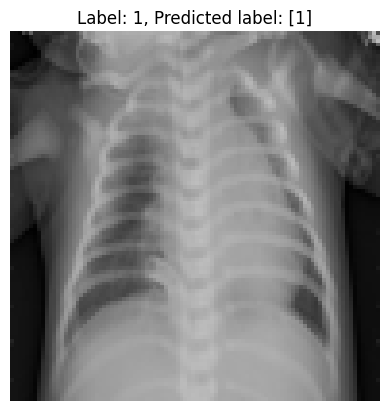

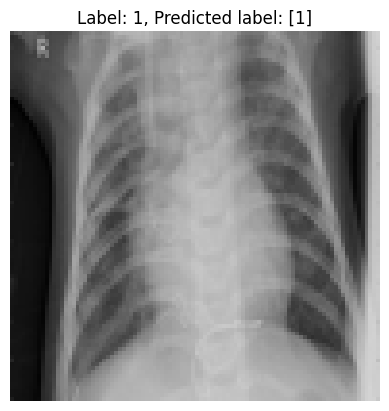

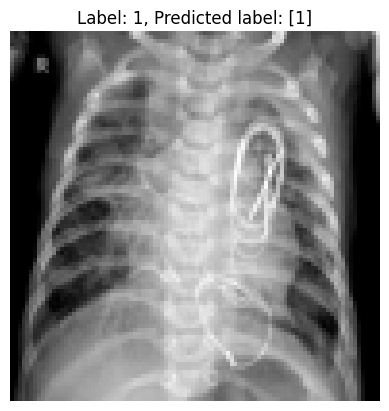

In [27]:
# ================================================================
# Изображения
# ================================================================

for i in range(10):

    plt.imshow(x_test[i+200])
    plt.title(f"Label: {y_test[i+200]}, Predicted label: {y_pred_classes[i+200]}")
    plt.axis('off')
    plt.show()

# Тюнинг CNN

In [8]:
from sklearn.utils import class_weight as cw

def cnn_model(
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    conv_layers=3,     # Количество сверточных блоков
    filters=32,        # Начальное количество фильтров
    n_units=64,        # Нейроны в полносвязном слое
    learning_rate=3e-4,
    batch_size=32,
    dropout=0.3,
    epochs=10,
    patience=5,
    verbose=1
):
    
    # ================================================================
    # 1. Расчет весов классов (решаем проблему дисбаланса)
    # ================================================================
    classes = np.unique(y_train)
    weights = cw.compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train
    )
    class_weights_dict = dict(zip(classes, weights))

    # ================================================================
    # 2. Создание модели
    # ================================================================
    model = tf.keras.Sequential()
    
    # Входной слой (96, 96, 3)
    model.add(tf.keras.layers.Input(shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3])))

    # Сверточный блок (циклом)
    for i in range(conv_layers):
        # Увеличиваем количество фильтров с глубиной (например, 32 -> 64 -> 128)
        model.add(tf.keras.layers.Conv2D(filters * (2**i), (3, 3), activation='relu', padding='same'))
        model.add(tf.keras.layers.BatchNormalization()) # Стабилизация обучения
        model.add(tf.keras.layers.MaxPooling2D((2, 2)))
        
    # Переход от карт признаков к вектору
    model.add(tf.keras.layers.Flatten())

    # Полносвязный блок (Dense)
    model.add(tf.keras.layers.Dense(n_units, activation='relu'))
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))

    # Выходной слой. 
    # Используем 1 нейрон и sigmoid для бинарной классификации (0 или 1)
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    # ================================================================
    # 3. Компиляция
    # ================================================================
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
    )

    # ================================================================
    # 4. Callbacks & Обучение
    # ================================================================
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss' if x_val is not None else 'loss',
            patience=patience,
            restore_best_weights=True,
            verbose=verbose
        )
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val) if x_val is not None else None,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights_dict, # ПРИМЕНЯЕМ ВЕСА
        callbacks=callbacks,
        verbose=verbose
    )

    return model, history.history

In [29]:
def objective(trial):

    conv_layers = trial.suggest_int('conv_layers', 1, 5, step=1) # 1. Количество сверточных слоев (блоков) - обычно от 1 до 5
    filters = trial.suggest_int('filters', 16, 64, step=16) # 2. Начальное количество фильтров (степень двойки: 16, 32, 64)
    n_units = trial.suggest_int('n_units', 32, 256, step=32) # 3. Количество нейронов в полносвязном (Dense) слое
    dropout = trial.suggest_float('dropout', 0, 0.5, step=0.1) # 4. Вероятность Dropout (от 0.1 до 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True) # 5. Скорость обучения

    model, history = cnn_model(
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        conv_layers=conv_layers,
        filters=filters,
        n_units=n_units, 
        learning_rate=learning_rate,
        batch_size=BATCH_SIZE,
        dropout=dropout,
        epochs=EPOCHS,
        patience=5,
        verbose=0
    )

    y_pred = model.predict(x_val, batch_size=BATCH_SIZE, verbose=0)

    y_pred_classes = (y_pred > 0.5).astype("int32")

    score = recall_score(y_val, y_pred_classes, average='macro')

    del model, history, y_pred, y_pred_classes

    gc.collect()
    tf.keras.backend.clear_session()

    return score

In [30]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=5,
    multivariate=True,
    group=True,
    constant_liar=True
)

study = optuna.create_study(direction='maximize', sampler=sampler)

[I 2026-05-22 14:22:19,061] A new study created in memory with name: no-name-ffd15094-5833-4c45-94e5-56794d3ba8c8


In [31]:
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1
)

  0%|          | 0/50 [00:00<?, ?it/s]

I0000 00:00:1779441740.986134   60498 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37277__.71
I0000 00:00:1779441744.996353   60499 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37277__.71


[I 2026-05-22 14:22:43,356] Trial 0 finished with value: 0.9482337704016137 and parameters: {'conv_layers': 4, 'filters': 16, 'n_units': 192, 'dropout': 0.2, 'learning_rate': 1.6619672516884586e-05}. Best is trial 0 with value: 0.9482337704016137.


I0000 00:00:1779441765.540280   60501 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_64877__.86
I0000 00:00:1779441771.029740   60502 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_64877__.86


[I 2026-05-22 14:23:11,734] Trial 1 finished with value: 0.9334349593495934 and parameters: {'conv_layers': 5, 'filters': 48, 'n_units': 256, 'dropout': 0.1, 'learning_rate': 0.000743376872545051}. Best is trial 0 with value: 0.9482337704016137.


...

[I 2026-05-22 14:42:17,731] Trial 47 finished with value: 0.9677757656335961 and parameters: {'conv_layers': 5, 'filters': 64, 'n_units': 256, 'dropout': 0.5, 'learning_rate': 0.0003321654861676282}. Best is trial 15 with value: 0.9754187297512072.


I0000 00:00:1779442940.445431   60501 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1023570__.86
I0000 00:00:1779442946.260436   60499 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1023570__.86


[I 2026-05-22 14:42:38,722] Trial 48 finished with value: 0.952493657925301 and parameters: {'conv_layers': 5, 'filters': 32, 'n_units': 160, 'dropout': 0.1, 'learning_rate': 0.00030690025719278723}. Best is trial 15 with value: 0.9754187297512072.


I0000 00:00:1779442961.154293   60503 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1040564__.70
I0000 00:00:1779442963.491256   60502 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1040564__.70


[I 2026-05-22 14:43:01,020] Trial 49 finished with value: 0.9715523565010087 and parameters: {'conv_layers': 4, 'filters': 48, 'n_units': 128, 'dropout': 0.0, 'learning_rate': 0.0002900758703576389}. Best is trial 15 with value: 0.9754187297512072.


In [32]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False)
trials_df.to_csv('tuning.csv')
trials_df

,number,value,datetime_start,datetime_complete,duration,params_conv_layers,params_dropout,params_filters,params_learning_rate,params_n_units,system_attrs_tpe:relative_params:0,state
15,15,0.975419,2026-05-22 14:28:28.830526,2026-05-22 14:28:55.908078,0 days 00:00:27.077552,5,0.0,48,0.000544,128,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
11,11,0.971938,2026-05-22 14:26:53.009223,2026-05-22 14:27:16.238953,0 days 00:00:23.229730,4,0.4,48,0.000025,128,"{""conv_layers"": 4, ""dropout"": 0.4, ""filters"": ...",COMPLETE
49,49,0.971552,2026-05-22 14:42:39.305598,2026-05-22 14:43:01.020447,0 days 00:00:21.714849,4,0.0,48,0.000290,128,"{""conv_layers"": 4, ""dropout"": 0.0, ""filters"": ...",COMPLETE
7,7,0.970005,2026-05-22 14:24:50.699936,2026-05-22 14:25:24.874359,0 days 00:00:34.174423,5,0.0,64,0.000136,128,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
24,24,0.968360,2026-05-22 14:32:11.492759,2026-05-22 14:32:38.599027,0 days 00:00:27.106268,4,0.1,64,0.000054,192,"{""conv_layers"": 4, ""dropout"": 0.1, ""filters"": ...",COMPLETE
44,44,0.968263,2026-05-22 14:40:05.930073,2026-05-22 14:40:40.453782,0 days 00:00:34.523709,5,0.4,64,0.000021,96,"{""conv_layers"": 5, ""dropout"": 0.4, ""filters"": ...",COMPLETE
8,8,0.968165,2026-05-22 14:25:25.083501,2026-05-22 14:25:57.230935,0 days 00:00:32.147434,5,0.3,64,0.000015,64,"{""conv_layers"": 5, ""dropout"": 0.30000000000000...",COMPLETE
47,47,0.967776,2026-05-22 14:41:44.063532,2026-05-22 14:42:17.731814,0 days 00:00:33.668282,5,0.5,64,0.000332,256,"{""conv_layers"": 5, ""dropout"": 0.5, ""filters"": ...",COMPLETE
36,36,0.967296,2026-05-22 14:36:44.680539,2026-05-22 14:37:12.730771,0 days 00:00:28.050232,5,0.0,64,0.000100,128,"{""conv_layers"": 5, ""dropout"": 0.0, ""filters"": ...",COMPLETE
41,41,0.967004,2026-05-22 14:38:34.730708,2026-05-22 14:39:12.451930,0 days 00:00:37.721222,5,0.4,64,0.000014,32,"{""conv_layers"": 5, ""dropout"": 0.4, ""filters"": ...",COMPLETE


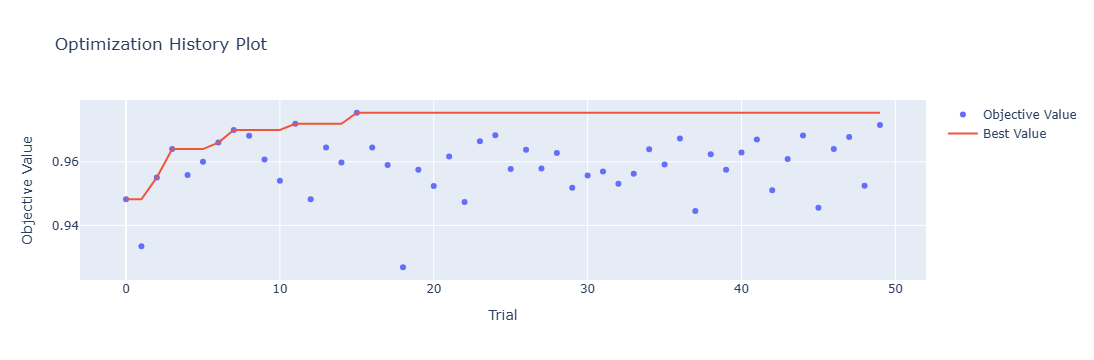

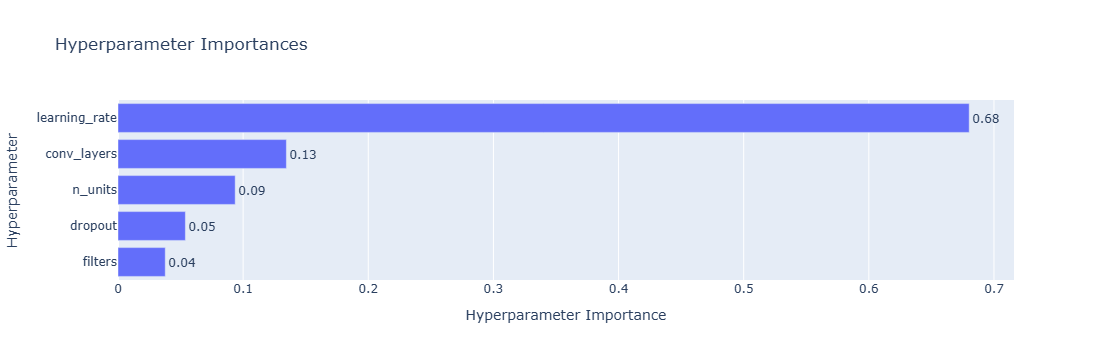

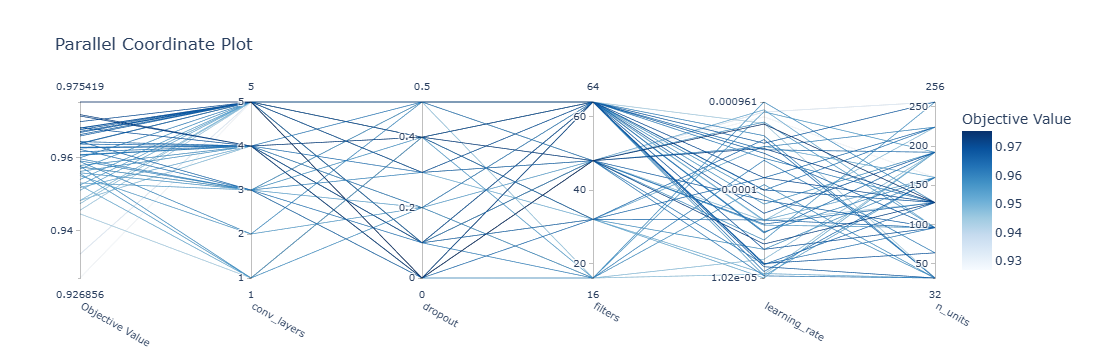

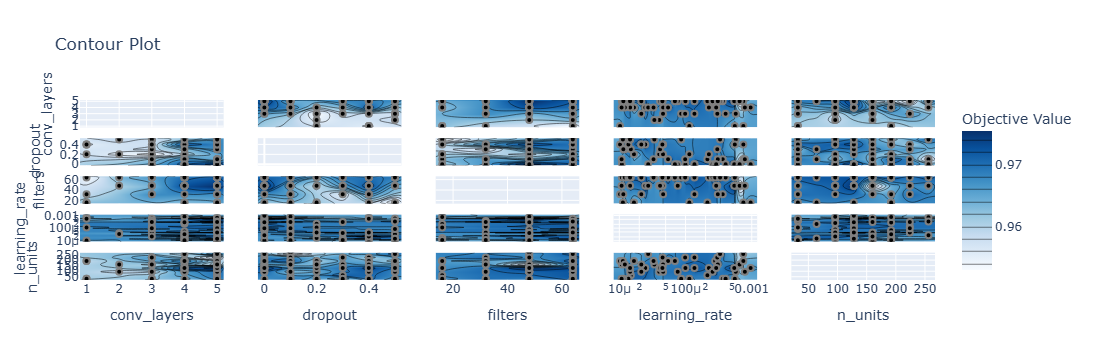

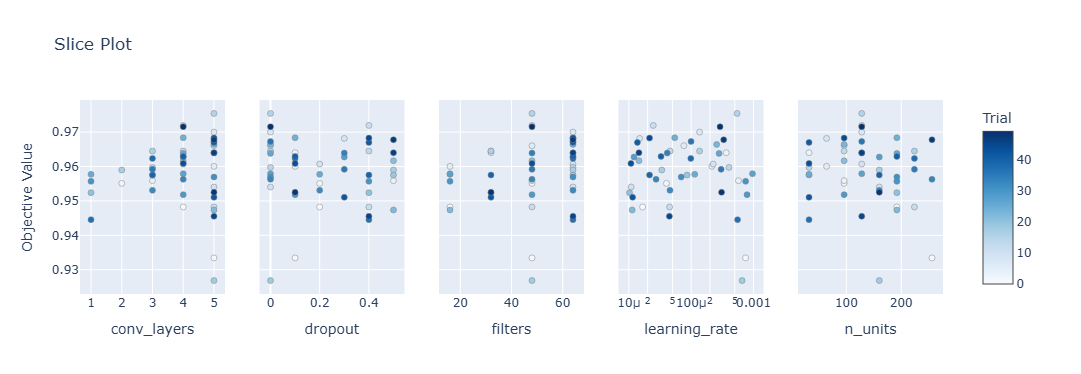

In [33]:
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour, plot_slice

plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_parallel_coordinate(study).show()
plot_contour(study).show()
plot_slice(study).show()

In [34]:
print("Лучшие параметры:", study.best_params)
print("Лучший value:", study.best_value)

Лучшие параметры: {'conv_layers': 5, 'filters': 48, 'n_units': 128, 'dropout': 0.0, 'learning_rate': 0.0005440445336462885}
Лучший value: 0.9754187297512072


# Обучение модели с наилучшей конфигурацией гиперпараметров

In [9]:
conv_layers = 5
filters = 48
n_units = 128
dropout = 0
learning_rate = 0.0005440445336462885

In [10]:
model, history = cnn_model(
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    conv_layers=conv_layers,
    filters=filters,
    n_units=n_units, 
    learning_rate=learning_rate,
    batch_size=BATCH_SIZE,
    dropout=dropout,
    epochs=EPOCHS,
    patience=5,
    verbose=1
)

W0000 00:00:1779521417.685260     518 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779521417.687060     518 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779521417.906126     518 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


Epoch 1/20


I0000 00:00:1779521420.849367    1943 service.cc:153] XLA service 0x73674c04eb80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779521420.849385    1943 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779521420.897349    1943 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779521421.191664    1943 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779521421.212367    1943 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5140__.85


  4/128 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5384 - loss: 6.0296 - precision: 0.8232 - recall: 0.4994 

I0000 00:00:1779521426.638619    1943 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


124/128 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8362 - loss: 1.0478 - precision: 0.9460 - recall: 0.8243

I0000 00:00:1779521428.614528    1942 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5140__.85


128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.8965 - loss: 0.4062 - precision: 0.9640 - recall: 0.8914 - val_accuracy: 0.7391 - val_loss: 5.5290 - val_precision: 0.7391 - val_recall: 1.0000
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9463 - loss: 0.1543 - precision: 0.9771 - recall: 0.9485 - val_accuracy: 0.7391 - val_loss: 4.6371 - val_precision: 0.7391 - val_recall: 1.0000
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9566 - loss: 0.1103 - precision: 0.9827 - recall: 0.9573 - val_accuracy: 0.7391 - val_loss: 1.2056 - val_precision: 0.7391 - val_recall: 1.0000
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9617 - loss: 0.1009 - precision: 0.9855 - recall: 0.9617 - val_accuracy: 0.8077 - val_loss: 0.6927 - val_precision: 0.7941 - val_recall: 0.9988
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9774 - loss: 0.0673 - precision: 0.9898 - recall: 0.9791 - val_accuracy: 0.9639 - val_loss: 0.1099 

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 48)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 192)    │       166,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 768)      │     2,654,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 768)      │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 768)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6912)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       884,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,250,597 (50.55 MB)

 Trainable params: 4,415,873 (16.85 MB)

 Non-trainable params: 2,976 (11.62 KB)

 Optimizer params: 8,831,748 (33.69 MB)

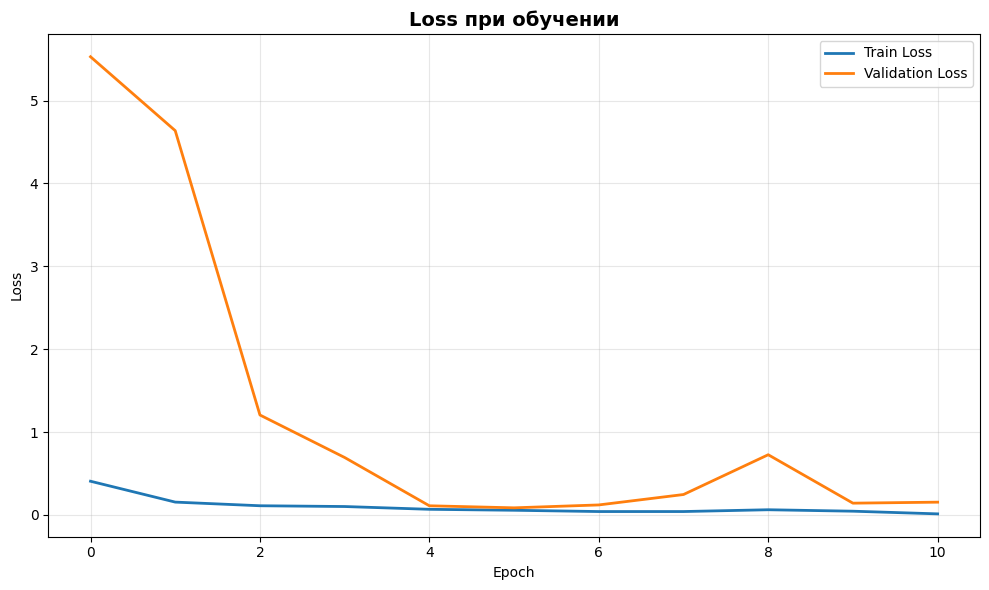

In [12]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history['loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test, verbose=1, batch_size=BATCH_SIZE)

# # Если вероятность > 0.5, то это 1 (пневмония), иначе 0 (норма)
y_pred_classes = (y_pred > 0.5).astype("int32")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


In [14]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       171
           1       0.97      0.97      0.97       411

    accuracy                           0.96       582
   macro avg       0.95      0.95      0.95       582
weighted avg       0.96      0.96      0.96       582



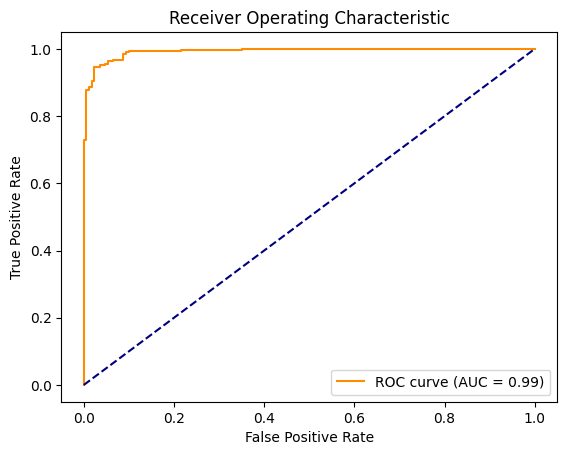

In [15]:
# ================================================================
# ROC-AUC
# ================================================================

# 1. FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Chance level
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

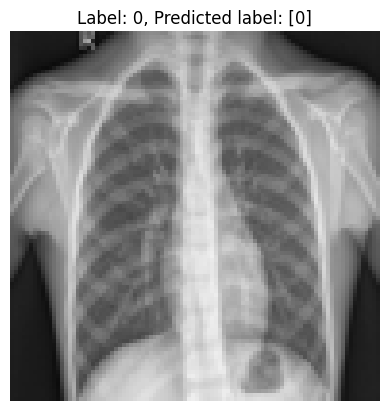

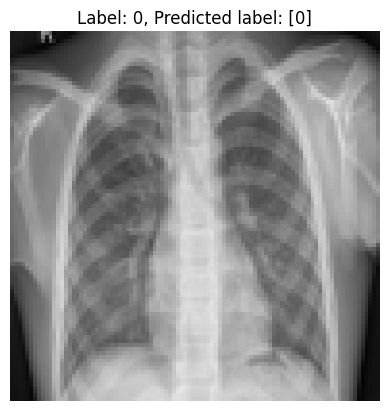

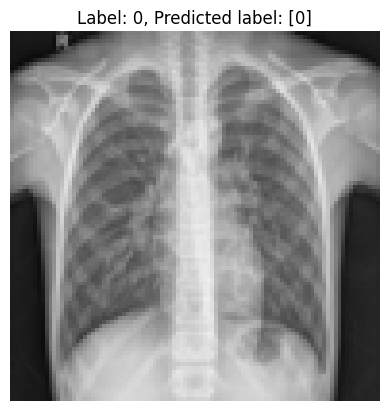

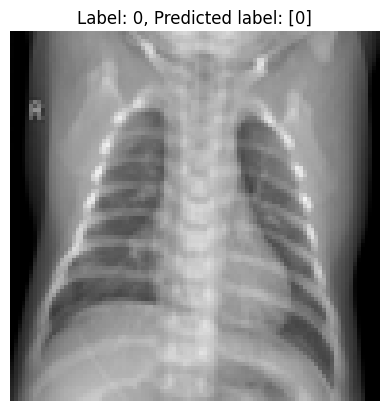

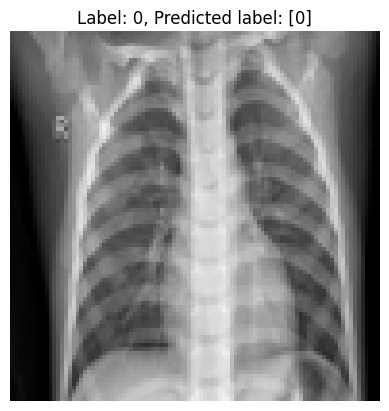

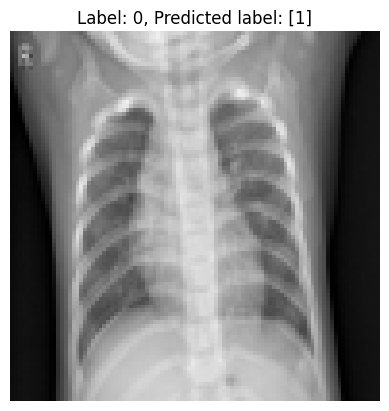

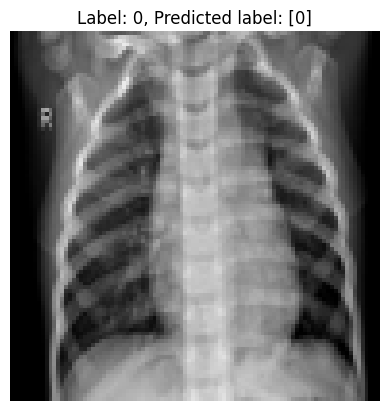

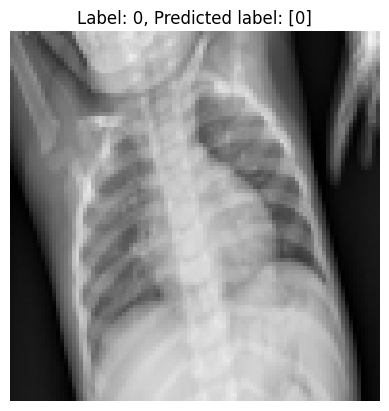

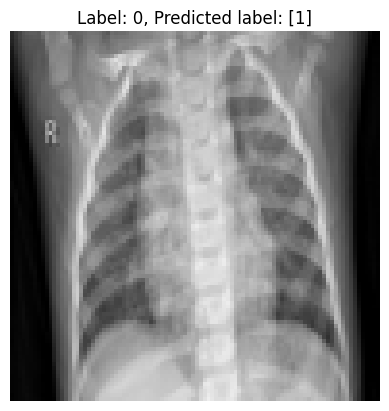

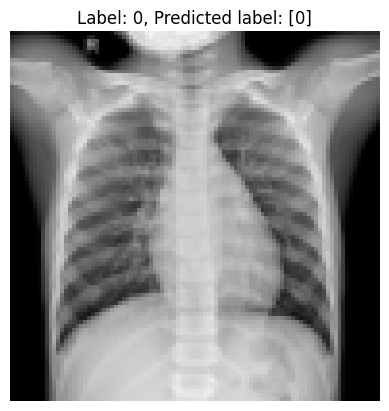

In [16]:
# ================================================================
# Изображения
# ================================================================

for i in range(10):

    plt.imshow(x_test[i])
    plt.title(f"Label: {y_test[i]}, Predicted label: {y_pred_classes[i]}")
    plt.axis('off')
    plt.show()

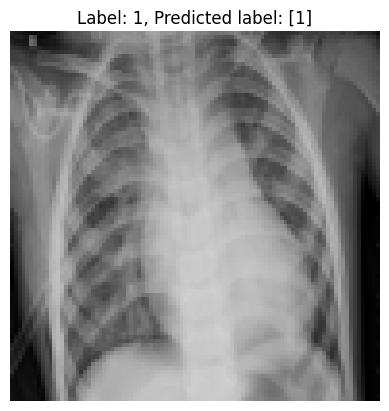

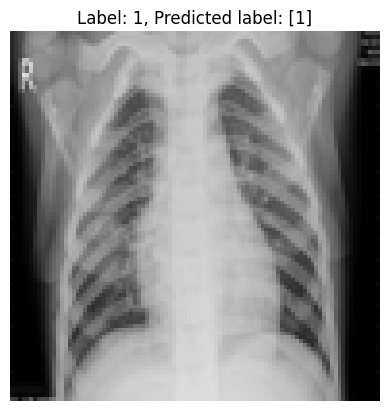

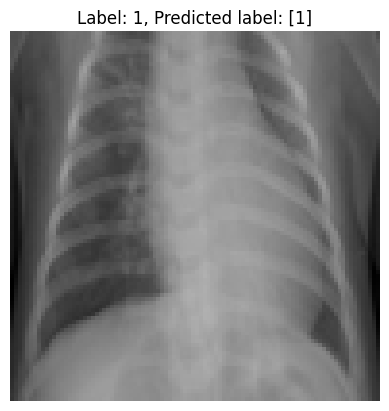

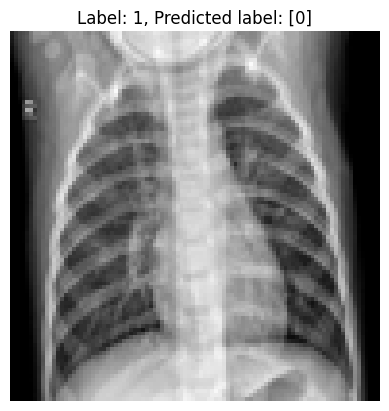

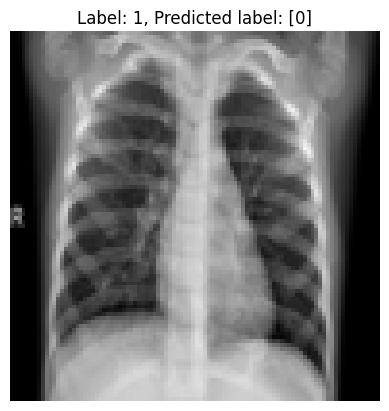

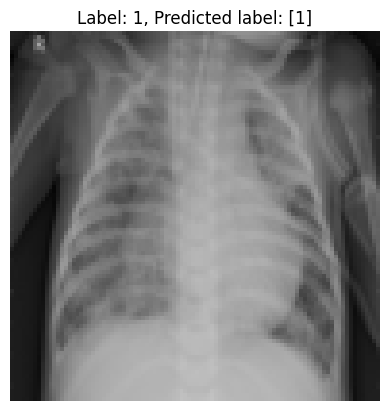

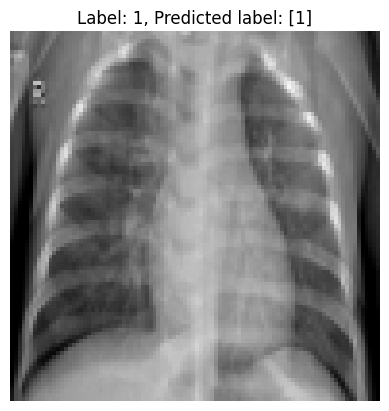

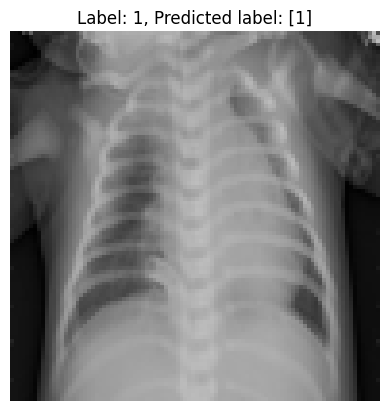

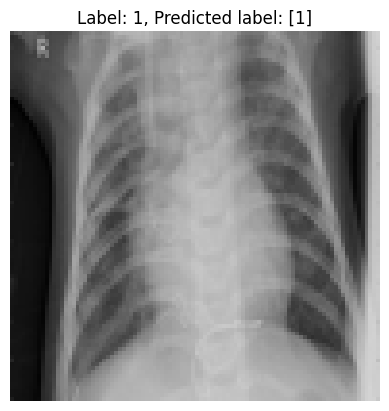

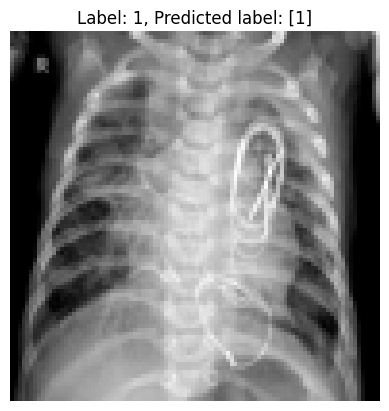

In [17]:
# ================================================================
# Изображения
# ================================================================

for i in range(10):

    plt.imshow(x_test[i+200])
    plt.title(f"Label: {y_test[i+200]}, Predicted label: {y_pred_classes[i+200]}")
    plt.axis('off')
    plt.show()